   Age  Gender   BMI  Pain_Score  ROM  Muscle_Strength  Sessions  \
0   25    Male  22.5           3   90                5         5   
1   40  Female  27.8           7   60                3        12   
2   55    Male  30.2           8   50                2        18   
3   30  Female  24.1           2   95                5         4   
4   45    Male  29.5           6   70                3        10   

  Exercise_Compliance  Recovery_Days  
0                High             14  
1              Medium             35  
2                 Low             60  
3                High             12  
4              Medium             30  
First 5 Rows:
   Age  Gender   BMI  Pain_Score  ROM  Muscle_Strength  Sessions  \
0   25    Male  22.5           3   90                5         5   
1   40  Female  27.8           7   60                3        12   
2   55    Male  30.2           8   50                2        18   
3   30  Female  24.1           2   95                5         4   
4  

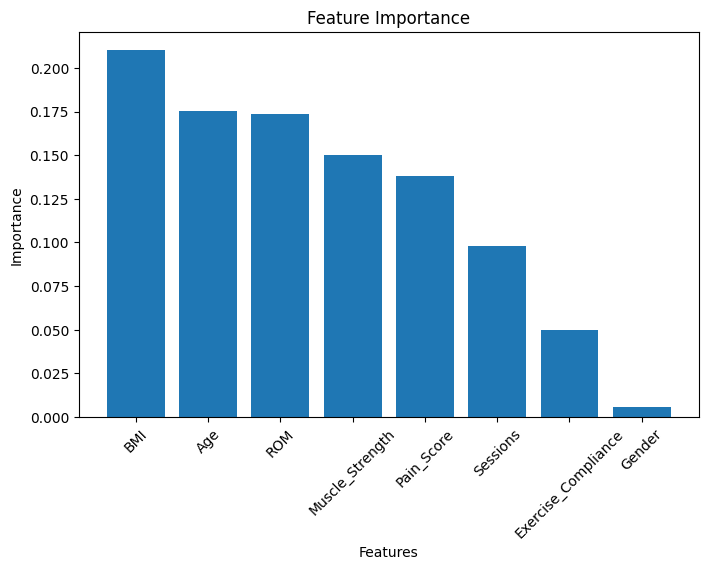

Correlation Matrix
                          Age    Gender       BMI  Pain_Score       ROM  \
Age                  1.000000 -0.429641  0.958358    0.895975 -0.955030   
Gender              -0.429641  1.000000 -0.438583   -0.299847  0.421896   
BMI                  0.958358 -0.438583  1.000000    0.910439 -0.947807   
Pain_Score           0.895975 -0.299847  0.910439    1.000000 -0.969720   
ROM                 -0.955030  0.421896 -0.947807   -0.969720  1.000000   
Muscle_Strength     -0.956015  0.333333 -0.962446   -0.963794  0.974135   
Sessions             0.958217 -0.396227  0.921649    0.947065 -0.982288   
Exercise_Compliance  0.547172 -0.361158  0.697897    0.593028 -0.605768   
Recovery_Days        0.963817 -0.433201  0.904527    0.916327 -0.964095   

                     Muscle_Strength  Sessions  Exercise_Compliance  \
Age                        -0.956015  0.958217             0.547172   
Gender                      0.333333 -0.396227            -0.361158   
BMI              

In [ ]:
# ===============================
# AI Physiotherapy Recovery Prediction System
# Step 1: Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

import joblib

# ==========================================
# Step 2: Create Physiotherapy Dataset
# ==========================================

data = {
    "Age": [25, 40, 55, 30, 45, 60, 35, 50, 28, 65],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female"],
    "BMI": [22.5, 27.8, 30.2, 24.1, 29.5, 31.0, 23.7, 28.4, 21.9, 32.1],
    "Pain_Score": [3, 7, 8, 2, 6, 9, 4, 5, 3, 8],
    "ROM": [90, 60, 50, 95, 70, 45, 85, 65, 92, 40],
    "Muscle_Strength": [5, 3, 2, 5, 3, 2, 4, 3, 5, 2],
    "Sessions": [5, 12, 18, 4, 10, 20, 6, 11, 5, 22],
    "Exercise_Compliance": ["High", "Medium", "Low", "High", "Medium", "Low", "High", "Medium", "High", "Low"],
    "Recovery_Days": [14, 35, 60, 12, 30, 75, 18, 40, 15, 80]
}

df = pd.DataFrame(data)

print(df.head())

# ==========================================
# Step 3: Explore the Dataset
# ==========================================

# First 5 rows
print("First 5 Rows:")
print(df.head())

print("\n-------------------------")

# Dataset Information
print("Dataset Information:")
print(df.info())

print("\n-------------------------")

# Statistical Summary
print("Statistical Summary:")
print(df.describe())

print("\n-------------------------")

# Missing Values
print("Missing Values:")
print(df.isnull().sum())

# ==========================================
# Step 4: Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Create Label Encoder
encoder = LabelEncoder()

# Convert Gender into Numbers
df["Gender"] = encoder.fit_transform(df["Gender"])

# Convert Exercise Compliance into Numbers
df["Exercise_Compliance"] = encoder.fit_transform(df["Exercise_Compliance"])

# Show Updated Dataset
print(df.head())

# ==========================================
# Step 5: Define Features and Target
# ==========================================

# Features (Input Data)
X = df.drop("Recovery_Days", axis=1)

# Target (Output)
y = df["Recovery_Days"]

# Display Features
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

# ==========================================
# Step 6: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Split the dataset into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)


# ==========================================
# Step 7: Train the Random Forest Model
# ==========================================

from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("✅ Model Training Completed Successfully!")

# ==========================================
# Step 8: Make Predictions
# ==========================================

# Predict Recovery Days
predictions = model.predict(X_test)

print("Predicted Recovery Days:")
print(predictions)

# ==========================================
# Step 9: Compare Actual vs Predicted
# ==========================================

comparison = pd.DataFrame({
    "Actual Recovery Days": y_test.values,
    "Predicted Recovery Days": predictions
})

print(comparison)

# ==========================================
# Step 10: Model Evaluation
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

# Print Results
print("Model Evaluation")
print("-----------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# ==========================================
# Step 11: Feature Importance
# ==========================================

# Get Feature Importance
importance = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort by Importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# ==========================================
# Step 12: Save the Trained Model
# ==========================================

import joblib

# Save the trained model
joblib.dump(model, "physiotherapy_recovery_model.pkl")

print("✅ Model saved successfully as physiotherapy_recovery_model.pkl")

# ==========================================
# Step 13: Load the Saved Model
# ==========================================

import joblib

# Load the saved model
loaded_model = joblib.load("physiotherapy_recovery_model.pkl")

print("✅ Model loaded successfully!")

# ==========================================
# Step 14: Predict Recovery for a New Patient
# ==========================================

import pandas as pd

# New Patient Data
new_patient = pd.DataFrame({
    "Age": [35],
    "Gender": [1],                 # Male = 1, Female = 0
    "BMI": [26.5],
    "Pain_Score": [6],
    "ROM": [75],
    "Muscle_Strength": [4],
    "Sessions": [8],
    "Exercise_Compliance": [2]     # Medium (according to our LabelEncoder)
})

# Predict Recovery Days
prediction = loaded_model.predict(new_patient)

print(f"Predicted Recovery Time: {prediction[0]:.2f} Days")

# ==========================================
# Step 15: Feature Importance Graph
# ==========================================

import matplotlib.pyplot as plt

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

# ==========================================
# Step 16: Correlation Matrix
# ==========================================

# Calculate Correlation
correlation = df.corr()

print("Correlation Matrix")
print(correlation)

# ==========================================
# Step 17: Compare Machine Learning Models
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Compare R² Scores
linear_r2 = r2_score(y_test, linear_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Linear Regression R² Score :", linear_r2)
print("Random Forest R² Score     :", rf_r2)
